<p class="mlx-kicker">Part II &middot; Architecture &middot; Chapter 4</p>

# 4. Token mixing: from convolution and recurrence to attention

<dl class="mlx-meta"><div><dt>Level</dt><dd>Intermediate</dd></div><div><dt>Reading</dt><dd>about 25 min</dd></div><div><dt>Hands-on</dt><dd>about 6 min on a laptop CPU</dd></div><div><dt>You should know</dt><dd>Chapter 1, matrix multiplication, softmax</dd></div></dl>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daiyip/ml-explained/blob/main/chapters/04-token-mixing/index.ipynb)

![Three ways for the last token of "The keys to the cabinet are" to reach the word "keys": a convolution sees only a fixed window of neighbours, a recurrent network must carry "keys" through a running state, and self-attention connects to it directly with a weight chosen by content.](figures/mixing-lineage.svg)

## What changed, and why it works

A Transformer block has two halves. The feed-forward layer (chapter 5) transforms each token on its own. The **token mixer** is the other half: the only place where one position can read information from another. To agree "are" with "keys" in *The keys to the cabinet are*, something must carry "keys" across four tokens. Figure 4.1 shows the three main ways this has been done, and this chapter asks why the third one won.

<div class="mlx-why">
<section class="mlx-why__card mlx-why__card--1"><p class="mlx-why__n">1 &middot; Convolution</p><h3>A fixed window with shared weights</h3><p><b>What changed.</b> Instead of connecting every input to every output, each output reads only a small window of k neighbours, with the same weights at every position (LeCun et al., 1989; AlexNet, 2012).</p><p><b>Why it works.</b> Nearby inputs are the most informative ones, in images and in text. Sharing one small kernel across positions cuts the parameter count by orders of magnitude and builds in the assumption that a pattern means the same thing wherever it appears. Stacking layers widens the window, but only linearly: L layers of width k reach L(k&minus;1)+1 positions.</p><p class="mlx-why__run">Our runs: recall 0.98 two tokens back, chance beyond seven; best Shakespeare loss, 1.708</p></section>
<section class="mlx-why__card mlx-why__card--2"><p class="mlx-why__n">2 &middot; Recurrence</p><h3>A running state, one step at a time</h3><p><b>What changed.</b> A recurrent network reads the sequence in order and updates a hidden state at every token. The LSTM (Hochreiter and Schmidhuber, 1997) adds gates that decide what to keep, and seq2seq (Sutskever et al., 2014) used it to translate whole sentences.</p><p><b>Why it works.</b> The state can in principle carry information over any distance, and the LSTM's additive cell update lets gradients flow back many steps without vanishing. The price is that everything the model knows about the past must fit in one fixed-size vector, and step t cannot start before step t&minus;1 finishes.</p><p class="mlx-why__run">Our runs: recall about 0.22 at every distance; Shakespeare loss 1.797</p></section>
<section class="mlx-why__card mlx-why__card--3"><p class="mlx-why__n">3 &middot; Self-attention</p><h3>Weights from content, over all pairs</h3><p><b>What changed.</b> Each token emits a query, a key and a value. It compares its query with every earlier key, turns the scores into weights with a softmax, and takes the weighted average of the values (Bahdanau et al., 2014; Vaswani et al., 2017).</p><p><b>Why it works.</b> The weights are computed from the content of the tokens, not fixed by their positions, so a token can fetch exactly the earlier token it needs, at any distance, in one step. Every position is computed at once with matrix multiplications, which GPUs do extremely well. The cost is T&sup2; pairs per layer and a cache of keys and values that grows with the context.</p><p class="mlx-why__run">Our runs: recall 1.00 at every distance in two seeds of three; Shakespeare loss 1.842, last of the three at this tiny scale</p></section>
</div>

Read left to right, the reach of a single layer grows from a fixed window, to unlimited but compressed, to unlimited and exact. Attention did not win on every measure, and our own language-model run shows a place where it loses. It won because it is the only one of the three that is both good at retrieval over long distances and parallel across positions during training, which is what scaling needed. The steps below rebuild each mixer and test that claim.

## Evolution path

| Year | Step | Level | What changed |
| --- | --- | --- | --- |
| 1989-1998 | Convolutional networks (LeNet) | minor | local, weight-shared filters for images |
| 2012 | AlexNet | **major** | a deep CNN trained on GPUs wins ImageNet by a wide margin |
| 2014 | VGG, Inception | minor | stacks of small 3&times;3 filters; parallel filters of several widths |
| 1997, 2014 | LSTM, seq2seq | **major** | gated recurrence; an encoder LSTM feeds a decoder LSTM to translate |
| 2014 | Bahdanau attention | **major** | the decoder looks back at all encoder states with learned weights |
| 2017 | Transformer | **major** | recurrence removed; multi-head self-attention does all the mixing |
| 2020 | Vision Transformer (ViT) | minor | the same attention applied to image patches |
| 2019-2024 | MQA, GQA, MLA | minor | share or compress keys and values to shrink the inference cache |
| 2020-2023 | FlashAttention, sliding windows | minor | exact attention with less memory traffic; attention limited to a local window |
| 2021-2023 | State-space models, Mamba | minor (a rival) | a recurrence again, but one that trains in parallel |

## The lineage post-mortem: what drove each replacement?

| Replacement | Pressure that drove it | What it bought |
| --- | --- | --- |
| fully connected to convolution | too many parameters, no notion of locality | weight sharing, translation invariance, trainable vision models |
| convolution to recurrence (for text) | sequences of any length, dependencies of any distance | unlimited reach in principle |
| seq2seq bottleneck to Bahdanau attention | a whole sentence squeezed into one vector | the decoder reads every encoder state directly |
| recurrence to self-attention | sequential steps that GPUs cannot parallelize | content-based reach at any distance, and training that scales |
| full attention to MQA, GQA, MLA, FlashAttention | memory: the key-value cache and the T&sup2; score matrix | cheaper inference at nearly the same quality |

Read top to bottom, the first replacements are about *what the model can express*: locality, then reach, then direct access. The later ones are about *what the hardware can afford*: parallel training, then memory at inference time. Attention sits at the turning point. It is not the most efficient mixer, but it was the first one that expressed long-range, content-based lookup and also matched what GPUs are good at.

**Still open:** whether attention's quadratic cost is fundamental. State-space models such as Mamba (Gu and Dao, 2023) match Transformers on many language benchmarks at small and medium scale while running in linear time, but they lag on tasks that need exact recall of something far back in the context. Hybrids that mix a few attention layers into a mostly recurrent or convolutional stack are an active bet, and it is not settled how few attention layers are enough.

## Diverged branches

The evolution path follows the line today's models inherited. At a few points the field split instead: two camps made different bets on the same problem, and sometimes both bets are still alive. Each tab below is one such fork, with the two branches, why they split, and how it has played out so far.

<div class="mlx-why mlx-forks" data-label="Forks in this lineage">
<section class="mlx-why__card mlx-why__card--1 mlx-fork"><p class="mlx-why__n">Fork 1 &middot; 2020-2022</p><h3>Images: attention or convolution?</h3><div class="mlx-fork__sides"><div class="mlx-fork__side"><p class="mlx-fork__name">Vision Transformer <span class="mlx-fork__state mlx-fork__state--main">mainline</span></p><p>Split the image into patches and let self-attention mix them, exactly as for text.</p><p class="mlx-fork__who">ViT, Swin, most multimodal vision encoders</p></div><span class="mlx-fork__vs" aria-hidden="true">vs</span><div class="mlx-fork__side"><p class="mlx-fork__name">Modernized ConvNet <span class="mlx-fork__state mlx-fork__state--alive">still used</span></p><p>Take a ResNet and apply ViT's design choices one at a time: a patchify stem, larger 7&times;7 kernels, LayerNorm, GELU, fewer activations.</p><p class="mlx-fork__who">ConvNeXt, efficient and on-device vision</p></div></div><p><b>Why they split.</b> ViT's 2020 win mixed two changes: attention, and a modern training recipe (AdamW, heavy augmentation, long schedules). Liu et al. (2022) asked how much of the gain was the recipe.</p><p><b>How it played out.</b> Much of it was: ConvNeXt matches Swin Transformers of the same size on ImageNet. ViT still won the long run because it is the same architecture as the language model, so the vision encoders in multimodal LLMs are almost all ViTs. <strong>[likely]</strong></p></section>
<section class="mlx-why__card mlx-why__card--2 mlx-fork"><p class="mlx-why__n">Fork 2 &middot; 2020-2022</p><h3>Approximate attention, or exact attention made fast?</h3><div class="mlx-fork__sides"><div class="mlx-fork__side"><p class="mlx-fork__name">Approximate attention <span class="mlx-fork__state mlx-fork__state--niche">niche</span></p><p>Change the math to cut the quadratic cost: attend only within a window plus a few global tokens (Longformer), or replace the softmax with a kernel so attention becomes linear in length (Performer).</p><p class="mlx-fork__who">Longformer, Performer, linear attention</p></div><span class="mlx-fork__vs" aria-hidden="true">vs</span><div class="mlx-fork__side"><p class="mlx-fork__name">Exact attention, faster kernels <span class="mlx-fork__state mlx-fork__state--main">mainline</span></p><p>Keep softmax attention exactly, but compute it in tiles held in fast on-chip memory, so the full score matrix never reaches main GPU memory.</p><p class="mlx-fork__who">FlashAttention, now in almost every stack</p></div></div><p><b>Why they split.</b> Quadratic cost capped context at a few thousand tokens. One camp changed the computation; the other changed how it touches memory.</p><p><b>How it played out.</b> Exact attention won. Approximations lost quality on tasks that need precise retrieval, and their speedups often failed to show up on real GPUs. Local windows survived as a mix: Mistral 7B uses sliding-window attention, and Gemma 2 alternates local and global layers. <strong>[likely]</strong></p></section>
<section class="mlx-why__card mlx-why__card--3 mlx-fork"><p class="mlx-why__n">Fork 3 &middot; 2023-2025</p><h3>Attention, or a state-space recurrence?</h3><div class="mlx-fork__sides"><div class="mlx-fork__side"><p class="mlx-fork__name">Attention <span class="mlx-fork__state mlx-fork__state--main">mainline</span></p><p>Every token can look at every earlier token; the KV cache grows with the context.</p><p class="mlx-fork__who">Transformers</p></div><span class="mlx-fork__vs" aria-hidden="true">vs</span><div class="mlx-fork__side"><p class="mlx-fork__name">Selective state space <span class="mlx-fork__state mlx-fork__state--rival">contender</span></p><p>A recurrence with a fixed-size state whose updates depend on the input, trained in parallel. Memory and compute per token stay constant however long the context.</p><p class="mlx-fork__who">Mamba; hybrids such as Jamba</p></div></div><p><b>Why they split.</b> Long contexts make attention's cache the bottleneck at inference. A recurrence has none, and Mamba removed the old reason for dropping RNNs: they can now train as fast as Transformers.</p><p><b>How it played out.</b> Pure state-space models trail attention when a task needs exact recall from far back, which a fixed-size state must compress (Jelassi et al., 2024; step 2's recall experiment shows the same limit for an LSTM). The branches are merging: hybrids keep a few attention layers among many Mamba layers. <strong>[likely]</strong></p></section>
</div>

## Run it yourself

The steps share this setup and one small model skeleton: embed the tokens, then stack blocks of *mixer, then feed-forward layer*, each with a residual connection and RMSNorm. Only the mixer changes between experiments, so any difference in the results comes from how tokens exchange information. Every experiment runs on a laptop CPU.

In [1]:
# Setup: works from a checkout of the repo and on Google Colab.
import pathlib, subprocess, sys

try:
    import mlexp
except ImportError:
    root = pathlib.Path.cwd().resolve().parents[1]
    if (root / "mlexp").is_dir():
        sys.path.insert(0, str(root))
    else:  # Colab: install the shared helpers from GitHub
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/daiyip/ml-explained"], check=True)
    import mlexp

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
mlexp.setup_style()
device_note = "GPU available" if torch.cuda.is_available() else "running on CPU"
print(f"torch {torch.__version__}, {device_note}")

torch 2.14.1+cu130, running on CPU


In [2]:
import time
from mlexp.transformer import RMSNorm, SwiGLU, apply_rope

torch.set_num_threads(1)  # the book builds several chapters at once; raise this on your own machine
tok, train_ids, val_ids = mlexp.load_char_corpus()


class MixerBlock(nn.Module):
    """Pre-norm block: x + mixer(norm(x)), then x + ffn(norm(x)). Only the mixer varies."""

    def __init__(self, dim, mixer):
        super().__init__()
        self.norm1, self.mixer = RMSNorm(dim), mixer
        self.norm2, self.ffn = RMSNorm(dim), SwiGLU(dim)

    def forward(self, x):
        x = x + self.mixer(self.norm1(x))
        return x + self.ffn(self.norm2(x))


class MixerLM(nn.Module):
    """Decoder-only language model whose token mixer is chosen by make_mixer(dim)."""

    def __init__(self, vocab_size, make_mixer, dim=64, n_layers=4):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, dim)
        self.blocks = nn.ModuleList(MixerBlock(dim, make_mixer(dim)) for _ in range(n_layers))
        self.norm = RMSNorm(dim)
        self.head = nn.Linear(dim, vocab_size, bias=False)

    def forward(self, idx, targets=None, include_aux=True):
        x = self.embed(idx)
        for block in self.blocks:
            x = block(x)
        logits = self.head(self.norm(x))
        if targets is None:
            return logits, None
        return logits, F.cross_entropy(logits.flatten(0, 1), targets.flatten())

### Step 1 (major): convolution, a fixed local window

#### The idea

A fully connected layer links every input to every output. For a 224 by 224 image that is billions of weights for a single layer, and none of them knows that neighbouring pixels belong together. A **convolution** makes two assumptions instead. *Locality*: each output depends only on a small window of nearby inputs. *Weight sharing*: the same window of weights, the **kernel**, slides over every position, so an edge detector learned in one corner works everywhere.

LeCun et al. (1989) used this to read handwritten digits. AlexNet (Krizhevsky, Sutskever and Hinton, 2012) trained a deep convolutional network on two GPUs and won the ImageNet competition by a wide margin, which started the deep-learning boom. VGG (Simonyan and Zisserman, 2014) showed that stacks of tiny 3 by 3 kernels work better than a few large ones: two stacked 3 by 3 layers see a 5 by 5 patch with fewer parameters and an extra nonlinearity in between. Inception (Szegedy et al., 2014) ran kernels of several widths side by side.

For text the same idea is a **1-D causal convolution**: the output at position t is a learned mix of the inputs at t, t&minus;1, ..., t&minus;k+1, and never of future tokens. WaveNet (2016) and ByteNet (2016) used stacks of these for audio and translation.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: a causal convolution and its reach</p><div class="mlx-eq">$$y_t = \sum_{j=0}^{k-1} W_j\, x_{t-j}, \qquad \text{reach after } L \text{ layers} = L\,(k-1) + 1$$</div><p class="mlx-eq__where">Each \(W_j\) is a \(d \times d\) matrix shared by every position \(t\). Which neighbours are mixed, and with what weights, is fixed after training: it does not depend on what the tokens say.</p></div>

#### Minimal implementation

We pad the sequence on the left with k&minus;1 zeros so that position t only sees the past.

In [3]:
class CausalConv(nn.Module):
    """Token mixer: each position mixes itself and the k-1 positions before it, with shared weights."""

    def __init__(self, dim, kernel=4):
        super().__init__()
        self.kernel = kernel
        self.conv = nn.Conv1d(dim, dim, kernel, bias=False)  # k matrices of size dim x dim

    def forward(self, x):  # x: (batch, time, dim)
        x = F.pad(x.transpose(1, 2), (self.kernel - 1, 0))  # zeros on the left: no peeking ahead
        return self.conv(x).transpose(1, 2)

#### Experiment: how far can a stack of convolutions see?

We stack L convolution layers with kernel 4, feed in 40 random token vectors, and ask which inputs the *last* output depends on. The gradient of that output with respect to each input is exactly zero for inputs it cannot see, so counting the non-zero gradients measures the reach.

In [4]:
def reach(mixers, T=40, dim=16):
    """Number of input positions that influence the output at the last position."""
    x = torch.randn(1, T, dim, requires_grad=True)
    h = x
    for m in mixers:
        h = h + m(h)  # residual, as in the real blocks
    h[0, -1].sum().backward()
    influenced = x.grad[0].abs().sum(-1) > 0
    return int(influenced.sum())


torch.manual_seed(0)
for L in [1, 2, 4, 8]:
    print(f"{L} conv layers, kernel 4: last token sees {reach([CausalConv(16) for _ in range(L)]):2d} of 40 positions"
          f"  (formula L(k-1)+1 = {L * 3 + 1})")

1 conv layers, kernel 4: last token sees  4 of 40 positions  (formula L(k-1)+1 = 4)
2 conv layers, kernel 4: last token sees  7 of 40 positions  (formula L(k-1)+1 = 7)
4 conv layers, kernel 4: last token sees 13 of 40 positions  (formula L(k-1)+1 = 13)
8 conv layers, kernel 4: last token sees 25 of 40 positions  (formula L(k-1)+1 = 25)


The reach grows by exactly k&minus;1 = 3 positions per layer. To link two words 100 tokens apart, this mixer needs over 30 layers, and even then the information has to be relayed through every layer in between. Dilated convolutions (WaveNet, ByteNet) double the gap at each layer and so grow the reach exponentially, but the core limitation stays: *which* positions get mixed is fixed by the architecture, not chosen by what the tokens say.

### Step 2 (major): recurrence, from LSTM to seq2seq

#### The idea

A **recurrent network** reads one token at a time and keeps a hidden state `\(h_t\)` that summarizes everything so far: `\(h_t = f(h_{t-1}, x_t)\)`. The reach is unlimited, since `\(h_t\)` depends on every earlier token. In practice simple recurrent networks forget quickly, because the gradient through many steps is a long product of Jacobians that shrinks (or explodes), the same problem as deep sigmoid stacks in chapter 5.

The **LSTM** (Hochreiter and Schmidhuber, 1997) fixed most of this with a separate *cell state* `\(c_t\)` that is updated by addition, under the control of gates. When the forget gate is near 1 and the input gate near 0, the cell copies itself forward and the gradient passes through almost unchanged.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: the LSTM cell update</p><div class="mlx-eq">$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t, \qquad h_t = o_t \odot \tanh(c_t)$$</div><p class="mlx-eq__where">The forget, input and output gates \(f_t, i_t, o_t\) and the candidate \(\tilde c_t\) are each computed from \([h_{t-1}, x_t]\) by a linear layer, with a sigmoid for the gates and tanh for the candidate. The additive path through \(c_t\) is what keeps gradients alive over many steps.</p></div>

**Seq2seq** (Sutskever, Vinyals and Le, 2014; Cho et al., 2014) used one LSTM to read a sentence into its final state and a second LSTM to write the translation from that state. It worked surprisingly well, but it exposed the **bottleneck**: the whole source sentence had to fit in one fixed-size vector, and quality fell off on long sentences. Bahdanau, Cho and Bengio (2014) removed the bottleneck by letting the decoder, at every output word, compute a weighted average over *all* encoder states, with weights from a small learned scoring network. That was the first attention mechanism in the modern sense, and it was still bolted onto an LSTM.

#### Minimal implementation

We use PyTorch's LSTM as the mixer. To keep the comparison fair we give it a narrower hidden state plus an output projection, so that it has about the same number of parameters as the convolution and attention mixers.

In [5]:
class LSTMMixer(nn.Module):
    """Token mixer: a running state read left to right. Width 0.56 * dim keeps parameters near 4 * dim^2."""

    def __init__(self, dim, hidden=None):
        super().__init__()
        hidden = hidden or int(0.56 * dim)
        self.lstm = nn.LSTM(dim, hidden, batch_first=True)
        self.out = nn.Linear(hidden, dim, bias=False)

    def forward(self, x):
        states, _ = self.lstm(x)  # (batch, time, hidden): h_1 ... h_T, computed one after another
        return self.out(states)


for name, m in [("CausalConv, kernel 4", CausalConv(64)), ("LSTMMixer", LSTMMixer(64))]:
    print(f"{name:22s} {mlexp.count_params(m):,} parameters at dim 64")

CausalConv, kernel 4   16,384 parameters at dim 64
LSTMMixer              16,380 parameters at dim 64


#### Experiment: recall a key from far back

To test reach directly, we use **associative recall**, a standard synthetic probe for token mixers (Ba et al., 2016; Arora et al., 2023). The input is a list of 10 key-value pairs followed by a query key, and the model must output the value that was paired with it:

`k7 v3  k2 v9  k5 v1  ...  k4 v6  |  k2  ->  v9`

Keys and values each come from 16 symbols, and the query picks one of the 10 keys at random. We record accuracy separately for each pair position, so we can see how performance depends on the distance between the query and the key it must find (2 tokens for the last pair, 20 for the first). Each model has two blocks of width 64 and trains for 1,000 steps. A 2-layer convolution with kernel 4 sees the last 7 tokens, so it can reach at most the last three pairs. Guessing among the 16 values gives about 6%.

In [6]:
N_PAIRS, N_SYM = 10, 16  # keys are tokens 0..15, values are tokens 16..31


def recall_batch(batch, gen):
    keys = torch.stack([torch.randperm(N_SYM, generator=gen)[:N_PAIRS] for _ in range(batch)])
    values = torch.randint(N_SYM, (batch, N_PAIRS), generator=gen) + N_SYM
    which = torch.randint(N_PAIRS, (batch,), generator=gen)  # the pair the query asks about
    rows = torch.arange(batch)
    seq = torch.stack([keys, values], dim=2).flatten(1)  # k v k v ... k v
    x = torch.cat([seq, keys[rows, which, None]], dim=1)  # ... then the query key
    return x, values[rows, which], which


def train_recall(make_mixer, steps=1000, seed=0):
    torch.manual_seed(seed)
    gen = torch.Generator().manual_seed(seed)
    model = MixerLM(2 * N_SYM, make_mixer, dim=64, n_layers=2)
    opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=0.0)
    for _ in range(steps):
        x, answer, _ = recall_batch(64, gen)
        logits, _ = model(x)
        loss = F.cross_entropy(logits[:, -1], answer)  # only the final prediction is scored
        opt.zero_grad()
        loss.backward()
        opt.step()
    with torch.no_grad():  # accuracy for each pair position on 4,000 fresh examples
        x, answer, which = recall_batch(4000, torch.Generator().manual_seed(99))
        pred = model(x)[0][:, -1].argmax(-1)
        acc = [(pred[which == i] == answer[which == i]).float().mean().item() for i in range(N_PAIRS)]
    return model, np.array(acc)


distance = 2 * (N_PAIRS - np.arange(N_PAIRS))  # tokens between the query and the key of each pair
recall = {}
for name, make in [("convolution", lambda d: CausalConv(d)), ("LSTM", lambda d: LSTMMixer(d))]:
    t0 = time.time()
    model, recall[name] = train_recall(make)
    print(f"{name:12s} {mlexp.count_params(model):,} params  mean accuracy {recall[name].mean():.2f}  ({time.time() - t0:.0f}s)")
    print("   by distance " + "  ".join(f"{d}:{a:.2f}" for d, a in zip(distance, recall[name])))

convolution  102,464 params  mean accuracy 0.24  (26s)
   by distance 20:0.06  18:0.07  16:0.06  14:0.07  12:0.05  10:0.09  8:0.05  6:0.36  4:0.58  2:0.98


LSTM         102,456 params  mean accuracy 0.22  (25s)
   by distance 20:0.26  18:0.21  16:0.23  14:0.21  12:0.20  10:0.22  8:0.20  6:0.25  4:0.22  2:0.24


#### Why it worked: a post-mortem

**The convolution does exactly what its reach predicts.** It scores 0.98 when the key is 2 tokens back, 0.58 at 4 and 0.36 at 6, and chance (about 0.06) for every key more than 7 tokens back. Positions outside the window are invisible, and no amount of training can change that. Inside the window it still has to learn which pattern to use, which is why accuracy already drops at 4 and 6 tokens. **[established]**

**The LSTM's accuracy is flat, at about 0.22 at every distance**, even for the pair just before the query. Distance is not its problem; capacity is. The model does not know which key will be asked until the end, so its state of 35 numbers must hold all 10 pairs at once, and in 1,000 steps it learned to keep only a little of each. A larger state and longer training would raise the score, but the state would have to grow with the number of pairs to remember. **[likely]** This is the seq2seq bottleneck in miniature: everything must squeeze through one fixed-size vector.

### Step 3 (major): self-attention

#### The idea

Bahdanau's decoder looked back at encoder states with learned weights. The Transformer (Vaswani et al., 2017) asked what happens if *every* token does this to every other token, and the recurrence is removed altogether. Each token's vector is projected three ways: a **query** (what am I looking for?), a **key** (what do I contain?) and a **value** (what do I pass on if chosen?). The score between two tokens is the dot product of one's query and the other's key; a softmax turns each row of scores into weights; the output is the weighted average of the values. A causal mask stops a token from attending to the future.

**Multi-head** attention runs several of these lookups in parallel on slices of the vector, so one head can track the previous token while another looks for the subject of the sentence. Unlike a convolution, which positions are mixed is decided at run time, from content. Unlike a recurrence, there is no state to squeeze information through, and all positions are computed at once.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: scaled dot-product attention</p><div class="mlx-eq">$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_h}} + M\right) V$$</div><p class="mlx-eq__where">\(Q, K, V\) are the queries, keys and values of all \(T\) tokens, \(d_h\) is the head width (dividing by \(\sqrt{d_h}\) keeps the scores from growing with it), and the mask \(M\) is \(-\infty\) above the diagonal. The \(T \times T\) score matrix is where both the power and the quadratic cost come from.</p></div>

#### Minimal implementation

This is the attention from chapter 1, with one extra argument we will need in step 4: `n_kv_heads`, the number of distinct key and value heads. With `n_kv_heads = n_heads` it is ordinary multi-head attention.

In [7]:
class Attention(nn.Module):
    """Causal multi-head self-attention with RoPE. n_kv_heads < n_heads gives GQA, n_kv_heads = 1 gives MQA."""

    def __init__(self, dim, n_heads=4, n_kv_heads=None):
        super().__init__()
        self.n_heads, self.n_kv = n_heads, n_kv_heads or n_heads
        self.head_dim = dim // n_heads
        self.q = nn.Linear(dim, dim, bias=False)
        self.kv = nn.Linear(dim, 2 * self.n_kv * self.head_dim, bias=False)
        self.out = nn.Linear(dim, dim, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        q = self.q(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)  # (B, heads, T, head_dim)
        k, v = self.kv(x).view(B, T, 2, self.n_kv, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k = apply_rope(q), apply_rope(k)  # position enters only through the rotation (chapter 3)
        share = self.n_heads // self.n_kv  # how many query heads read each key-value head
        k, v = k.repeat_interleave(share, dim=1), v.repeat_interleave(share, dim=1)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)  # softmax(QK^T / sqrt(d)) V
        return self.out(y.transpose(1, 2).reshape(B, T, C))


print(f"Attention, 4 heads     {mlexp.count_params(Attention(64)):,} parameters at dim 64")

Attention, 4 heads     16,384 parameters at dim 64


#### Experiment: the same recall task, with attention

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">The convolution reached only the last few pairs and the LSTM stayed far below perfect at every distance. The attention model has the same width, depth and parameter count. How will its accuracy depend on the distance to the key?</p><details><summary>Show what happened</summary><p>Attention scores 1.00 at every distance, from 2 tokens to 20. Distance makes no difference, because the query compares itself with every earlier position directly. This run is lucky, though: in one of the three seeds we ran, attention never found the trick within 1,000 steps and stayed at 0.19, no better than the LSTM.</p></details></div>

attention    102,464 params  mean accuracy 1.00  (36s)
   by distance 20:1.00  18:1.00  16:1.00  14:1.00  12:1.00  10:1.00  8:1.00  6:1.00  4:1.00  2:1.00


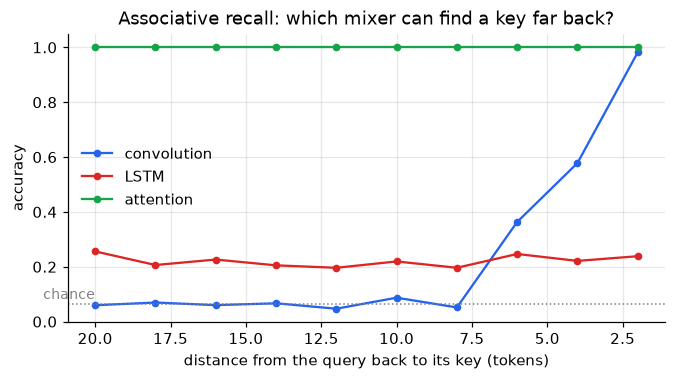

In [8]:
t0 = time.time()
attn_model, recall["attention"] = train_recall(lambda d: Attention(d))
print(f"attention    {mlexp.count_params(attn_model):,} params  mean accuracy {recall['attention'].mean():.2f}  ({time.time() - t0:.0f}s)")
print("   by distance " + "  ".join(f"{d}:{a:.2f}" for d, a in zip(distance, recall["attention"])))

fig, ax = plt.subplots(figsize=(7, 3.4))
for name, acc in recall.items():
    ax.plot(distance, acc, marker="o", ms=4, label=name)
ax.axhline(1 / N_SYM, color="gray", ls=":", lw=1)
ax.text(20, 1 / N_SYM + 0.02, "chance", color="gray", ha="right", fontsize=9)
ax.set(xlabel="distance from the query back to its key (tokens)", ylabel="accuracy",
       title="Associative recall: which mixer can find a key far back?", ylim=(0, 1.05))
ax.invert_xaxis()
ax.legend(frameon=False);

We can look inside the trained model. Below are the attention weights of the second layer at the query position, for one example: each head's weights over the 20 earlier tokens. Pairs are counted from 0, so pair 7 is the eighth key-value pair.

query key: ?k9   correct value: v0   most-attended token per head: ['v0', 'v0', 'v0', 'v0']


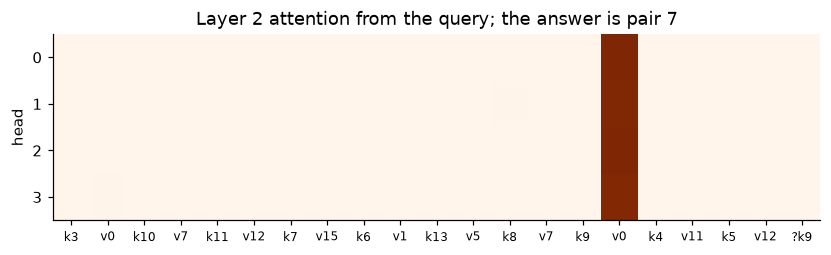

In [9]:
x, answer, which = recall_batch(1, torch.Generator().manual_seed(5))
captured = {}
block = attn_model.blocks[1]
handle = block.mixer.register_forward_hook(lambda m, inp, out: captured.update(x=inp[0]))
with torch.no_grad():
    attn_model(x)
handle.remove()

m, h = block.mixer, captured["x"]  # recompute the second layer's attention weights from its input
B, T, C = h.shape
q = apply_rope(m.q(h).view(B, T, m.n_heads, m.head_dim).transpose(1, 2))
k = apply_rope(m.kv(h).view(B, T, 2, m.n_kv, m.head_dim).permute(2, 0, 3, 1, 4)[0])
w = torch.softmax(torch.einsum("hd,htd->ht", q[0, :, -1], k[0]) / m.head_dim**0.5, dim=-1)  # (heads, T)

labels = [f"k{t}" if t < N_SYM else f"v{t - N_SYM}" for t in x[0, :-1].tolist()] + [f"?k{x[0, -1].item()}"]
fig, ax = plt.subplots(figsize=(9, 2.2))
ax.imshow(w.detach(), cmap="Oranges", aspect="auto", vmin=0, vmax=1)
ax.set(xticks=range(T), yticks=range(m.n_heads), ylabel="head", title=f"Layer 2 attention from the query; the answer is pair {which.item()}")
ax.set_xticklabels(labels, fontsize=8)
ax.grid(False);
print("query key:", labels[-1], "  correct value:", f"v{answer.item() - N_SYM}",
      "  most-attended token per head:", [labels[i] for i in w.argmax(-1).tolist()])

#### Experiment: a real language model at a fixed step budget

Recall is a probe built to need long-range lookup. Character-level Shakespeare is a more ordinary test: much of what predicts the next character is in the last few characters. We train the same three mixers as 4-block language models of width 64, with context 64 and 600 steps each, and record the wall-clock time.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">All three models have about 205,000 parameters and see the same batches. Which reaches the lowest validation loss after 600 steps, and which trains fastest per step on a single CPU thread?</p><details><summary>Show what happened</summary><p>The convolution wins clearly (1.708), the LSTM is second (1.797) and attention is last (1.842). Attention was also the slowest on one CPU thread: 65 s for 600 steps, against 45 s for the convolution and 46 s for the LSTM.</p></details></div>

convolution      params 204,992  final val loss 1.708  (45s)


LSTM             params 204,976  final val loss 1.797  (46s)


attention (MHA)  params 204,992  final val loss 1.842  (65s)


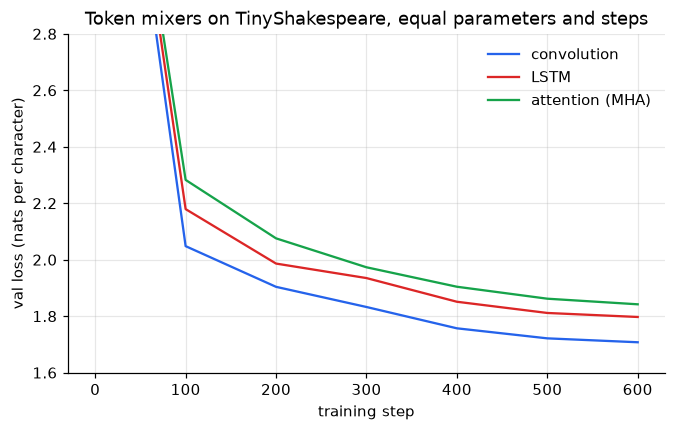

In [10]:
mixers = {
    "convolution": lambda d: CausalConv(d),
    "LSTM": lambda d: LSTMMixer(d),
    "attention (MHA)": lambda d: Attention(d, n_heads=4),
}
histories, seconds = {}, {}
for name, make in mixers.items():
    torch.manual_seed(0)
    model = MixerLM(tok.vocab_size, make)
    t0 = time.time()
    histories[name] = mlexp.train_lm(model, train_ids, val_ids, steps=600, block_size=64, eval_every=100, log=False)
    seconds[name] = time.time() - t0
    print(f"{name:16s} params {mlexp.count_params(model):,}  final val loss {histories[name]['val'][-1]:.3f}  ({seconds[name]:.0f}s)")

ax = mlexp.plot_histories(histories, "Token mixers on TinyShakespeare, equal parameters and steps")
ax.set_ylim(1.6, 2.8);

#### Why it worked: a post-mortem

**Attention solves recall perfectly, at every distance, once it finds the circuit.** The heatmap shows how. In layer 2, all four heads put nearly all their weight on the single value token that follows the matching key. For that to work, layer 1 must have copied each key into the value token after it, so that the query can find the value by matching content. This two-layer pattern is the *induction head* described by Olsson et al. (2022). Such circuits tend to appear suddenly during training, and in one of our three seeds it had not appeared after 1,000 steps, which left attention near the other mixers. **[likely]**, since we inspected one example rather than proving the circuit. The broader result, that attention solves associative recall easily while attention-free mixers struggle with it, matches Arora et al. (2023). **[established]**

**On Shakespeare, at this scale, attention loses.** The convolution beats it by 0.13 nats, and even the LSTM beats it. This is not a bug. For characters, most of the signal is in the last few characters, and a convolution stack (reach 13 here) has that locality built in. Attention has to learn from data that nearby positions matter, and 600 steps on a 205,000-parameter model is very little data. The same effect explains why the Vision Transformer only beat convolutional networks after pretraining on very large datasets (Dosovitskiy et al., 2020). **[likely]**

**So why did attention win?** For two reasons that a 600-step CPU run cannot show. The first is *retrieval*: real text is full of dependencies like our recall task, such as a name introduced pages earlier, and attention is the mixer that fetches them reliably. The second is *hardware*. On one CPU thread attention was our slowest mixer, but on a GPU it is the fastest to train: an LSTM must take T steps one after another, while attention is a few large matrix multiplications over all positions at once. Vaswani et al. (2017) reached better translation quality than recurrent and convolutional models at a fraction of their training cost. **[established]** A built-in locality bias helps when data is scarce; content-based reach plus parallel training wins once data and compute grow. **[likely]** Modern designs keep a little of both, for example sliding-window attention and the short convolution inside each Mamba block.

**Caveat on our numbers.** These are tiny models. Across three seeds the Shakespeare ranking (convolution, LSTM, attention) came out the same every time, with spreads under 0.02, so those gaps are real for this setup. The recall result is the fragile one: attention reached 1.00 in two seeds and 0.19 in the third, while the convolution and the LSTM never exceeded 0.24.

### Step 4 (minor): cheaper attention: MQA, GQA, MLA and FlashAttention

#### The problem before

Training computes all positions at once, but generation produces one token at a time. To avoid recomputing the past, a model stores every earlier token's keys and values in the **KV cache**. For a model with L layers, `\(n_{kv}\)` key-value heads of width `\(d_h\)`, and context T, the cache holds `\(2 \cdot L \cdot n_{kv} \cdot d_h \cdot T\)` numbers per sequence. For long contexts and many users at once, reading this cache from memory, not arithmetic, limits generation speed.

#### The idea

- **Multi-query attention** (MQA; Shazeer, 2019) keeps many query heads but only *one* key-value head that all of them share. The cache shrinks by the number of heads.
- **Grouped-query attention** (GQA; Ainslie et al., 2023) is the middle ground: groups of query heads share a key-value head. LLaMA 2 70B uses 64 query heads and 8 key-value heads, a cache 8 times smaller than full multi-head attention.
- **Multi-head latent attention** (MLA; DeepSeek-AI, 2024) caches one small compressed vector per token and expands it into keys and values on the fly.
- **FlashAttention** (Dao et al., 2022) changes no mathematics. It computes exact attention in tiles that fit in fast on-chip memory and never writes the T by T score matrix to main memory, which makes long contexts affordable in training.
- **Sliding-window attention** (Longformer, 2020; Mistral 7B, 2023) lets each token attend only to the last W tokens. It is a convolution's fixed window again, but with content-based weights inside it; stacked layers still relay information further back.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: KV-cache size</p><div class="mlx-eq">$$\text{cache bytes} = 2 \cdot L \cdot n_{kv} \cdot d_h \cdot T \cdot b$$</div><p class="mlx-eq__where">The factor 2 counts keys and values, and \(b\) is bytes per number (2 for 16-bit). MHA has \(n_{kv} = n_{\text{heads}}\), GQA \(1 < n_{kv} < n_{\text{heads}}\), MQA \(n_{kv} = 1\).</p></div>

#### Experiment: KV cache against loss

Our `Attention` class already supports this through `n_kv_heads`. We retrain the attention language model from step 3 with 2 key-value heads (GQA) and 1 (MQA), keeping 4 query heads.

In [11]:
def kv_bytes_per_token(n_layers, n_kv, head_dim, bytes_per=2):
    return 2 * n_layers * n_kv * head_dim * bytes_per


rows = [("attention (MHA)", 4)]
for name, n_kv in [("GQA, 2 kv heads", 2), ("MQA, 1 kv head", 1)]:
    torch.manual_seed(0)
    model = MixerLM(tok.vocab_size, lambda d, n=n_kv: Attention(d, n_heads=4, n_kv_heads=n))
    t0 = time.time()
    histories[name] = mlexp.train_lm(model, train_ids, val_ids, steps=600, block_size=64, eval_every=100, log=False)
    seconds[name] = time.time() - t0
    rows.append((name, n_kv))

print(f"{'variant':16s} {'kv heads':>8s} {'cache bytes/token':>18s} {'val loss':>9s}")
for name, n_kv in rows:
    print(f"{name:16s} {n_kv:8d} {kv_bytes_per_token(4, n_kv, 16):18,d} {histories[name]['val'][-1]:9.3f}")

# The same arithmetic at the scale of LLaMA 2 70B: 80 layers, 64 query heads of width 128, 8 kv heads.
for label, n_kv in [("MHA (64 kv heads)", 64), ("GQA (8 kv heads)", 8), ("MQA (1 kv head)", 1)]:
    gb = kv_bytes_per_token(80, n_kv, 128) * 4096 / 1e9
    print(f"70B-scale {label:18s}: {gb:5.2f} GB of cache for one 4,096-token sequence")

variant          kv heads  cache bytes/token  val loss
attention (MHA)         4              1,024     1.842
GQA, 2 kv heads         2                512     1.830
MQA, 1 kv head          1                256     1.856
70B-scale MHA (64 kv heads) : 10.74 GB of cache for one 4,096-token sequence
70B-scale GQA (8 kv heads)  :  1.34 GB of cache for one 4,096-token sequence
70B-scale MQA (1 kv head)   :  0.17 GB of cache for one 4,096-token sequence


Sharing key-value heads cost almost nothing here. GQA with half the cache reached 1.830 and MQA with a quarter of the cache reached 1.856, against 1.842 for full multi-head attention. Across three seeds GQA matched multi-head attention (1.842 against 1.839 on average), while MQA was behind in every seed, by 0.014 to 0.043. The GQA and MQA models also have slightly fewer parameters, because their key-value projection is smaller. At the scale of a 70-billion-parameter model the saving is large: 10.7 GB of cache per 4,096-token sequence with full multi-head attention, 1.3 GB with 8 key-value heads, 0.17 GB with one.

**[established]** that GQA nearly matches multi-head quality while decoding almost as fast as MQA (Ainslie et al., 2023), which is why LLaMA 2 70B, Llama 3 and Mistral use it. **[likely]** that MQA's single head costs some quality and stability at large scale, which is what pushed the field to the GQA compromise and then to MLA's compressed cache.

### Step 5 (minor): the rival: state-space models and Mamba

Attention's two costs, T&sup2; work in training and a cache that grows with T at inference, have kept recurrence alive. **State-space models** (S4; Gu, Goel and R&eacute;, 2021) are recurrences with a *linear* state update, `\(h_t = A h_{t-1} + B x_t\)`. Because the update is linear, the whole sequence can also be computed as one long convolution or a parallel scan, so they train in parallel like a Transformer and generate step by step like an RNN, with a fixed-size state instead of a growing cache. **Mamba** (Gu and Dao, 2023) made `\(A\)` and `\(B\)` depend on the current token, so the model can choose what to write into its state and what to forget, which is a step back toward content-based mixing.

This brings the lineage full circle: a convolution, a recurrence and attention are three answers to the same question, and modern designs mix them. **[established]** that Mamba-style models are competitive on language modelling at small and medium scale. **[likely]** that a fixed-size state is the reason they lag on exact recall of long contexts, the task in our step 2 experiment: Jelassi et al. (2024) prove that a model with a fixed-size state cannot copy strings longer than its state can hold, and show Transformers learn copying far faster in practice. **[speculative]** whether hybrids with a small fraction of attention layers (as in Jamba, 2024) will replace pure Transformers at the frontier.

## Across three seeds

The numbers on this page come from one run, seed 0. We reran the whole notebook twice more with every random seed shifted by 1 and by 2, which changes the initial weights, the batches and the evaluation samples (the `Seed runs` workflow in the repository does this for any chapter). A gap between two runs means something only when it is clearly larger than their spread.

| Run | This page (seed 0) | Mean ± sd, 3 seeds | Seeds 0 / 1 / 2 |
| --- | --- | --- | --- |
| recall accuracy, convolution | 0.24 | 0.20 ± 0.04 | 0.24 / 0.17 / 0.20 |
| recall accuracy, LSTM | 0.22 | 0.22 ± 0.01 | 0.22 / 0.22 / 0.21 |
| recall accuracy, attention | 1.00 | 0.73 ± 0.47 | 1.00 / 0.19 / 1.00 |
| Shakespeare, convolution | 1.708 | 1.722 ± 0.015 | 1.708 / 1.737 / 1.721 |
| Shakespeare, LSTM | 1.797 | 1.808 ± 0.014 | 1.797 / 1.824 / 1.804 |
| Shakespeare, attention (MHA) | 1.842 | 1.839 ± 0.003 | 1.842 / 1.836 / 1.838 |
| GQA, 2 kv heads | 1.830 | 1.842 ± 0.014 | 1.830 / 1.839 / 1.857 |
| MQA, 1 kv head | 1.856 | 1.863 ± 0.014 | 1.856 / 1.879 / 1.854 |

The Shakespeare ranking held in every seed. Attention's recall is bimodal: perfect in two seeds and near the others in the third, which is why its average is 0.73 with a large spread.

## Recap

<div class="mlx-box mlx-box--objectives"><p class="mlx-box__label">Recap</p><p>You should now be able to:</p><ol><li>Explain how convolution, recurrence and self-attention each move information between tokens, and what each one assumes.</li><li>Compute the reach of a stack of convolutions and explain the seq2seq bottleneck that Bahdanau attention removed.</li><li>Implement causal multi-head attention with grouped key-value heads, and compute its KV-cache size.</li><li>Say why attention won (content-based reach plus parallel training) and where it still loses (local patterns at tiny scale, quadratic cost, cache size).</li></ol></div>

<div class="mlx-box mlx-box--check"><p class="mlx-box__label">Check your understanding</p><details><summary>A stack of 6 causal convolutions with kernel 3. How many positions can the last output see, and how does attention change that?</summary><p>6 &times; (3 &minus; 1) + 1 = 13 positions. A single attention layer can read any earlier position, and which ones it reads is decided by the tokens' content rather than by their distance.</p></details><details><summary>Why can a Transformer be trained on a sequence much faster than an LSTM of the same size on a GPU?</summary><p>The LSTM must compute its state at step t before step t+1, so a sequence of length T takes T sequential steps. Attention computes all positions at once with a few large matrix multiplications, which keeps thousands of GPU cores busy.</p></details><details><summary>A model has 32 layers, 32 query heads of width 128, and 8 key-value heads. How large is its 16-bit KV cache per token, and how much larger would it be with full multi-head attention?</summary><p>2 &times; 32 &times; 8 &times; 128 &times; 2 bytes = 131,072 bytes, or 128 KiB per token. With 32 key-value heads it would be 4 times larger, 512 KiB per token.</p></details></div>

## Further reading

- Krizhevsky, Sutskever and Hinton, 2012, [ImageNet Classification with Deep Convolutional Neural Networks](https://papers.nips.cc/paper/2012/hash/c399862d3b9d6b76c8436e924a68c45b-Abstract.html): AlexNet.
- Hochreiter and Schmidhuber, 1997, [Long Short-Term Memory](https://doi.org/10.1162/neco.1997.9.8.1735).
- Sutskever, Vinyals and Le, 2014, [Sequence to Sequence Learning with Neural Networks](https://arxiv.org/abs/1409.3215).
- Bahdanau, Cho and Bengio, 2014, [Neural Machine Translation by Jointly Learning to Align and Translate](https://arxiv.org/abs/1409.0473).
- Vaswani et al., 2017, [Attention Is All You Need](https://arxiv.org/abs/1706.03762).
- Ainslie et al., 2023, [GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints](https://arxiv.org/abs/2305.13245); see also Shazeer, 2019, [Fast Transformer Decoding: One Write-Head is All You Need](https://arxiv.org/abs/1911.02150).
- Dao et al., 2022, [FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness](https://arxiv.org/abs/2205.14135).
- Gu and Dao, 2023, [Mamba: Linear-Time Sequence Modeling with Selective State Spaces](https://arxiv.org/abs/2312.00752); and Arora et al., 2023, [Zoology: Measuring and Improving Recall in Efficient Language Models](https://arxiv.org/abs/2312.04927).
- Liu et al., 2022, [A ConvNet for the 2020s](https://arxiv.org/abs/2201.03545).
- Beltagy, Peters and Cohan, 2020, [Longformer: The Long-Document Transformer](https://arxiv.org/abs/2004.05150).
- Choromanski et al., 2020, [Rethinking Attention with Performers](https://arxiv.org/abs/2009.14794).
- Lieber et al., 2024, [Jamba: A Hybrid Transformer-Mamba Language Model](https://arxiv.org/abs/2403.19887).
- Jelassi et al., 2024, [Repeat After Me: Transformers are Better than State Space Models at Copying](https://arxiv.org/abs/2402.01032).